# RCWA for a single interface between two non-magnetic and isotropic media

A plane wave in a semi-infinite medium 1 (permittivity `eps1`) is incident at
angle `theta` (from the surface normal) on a flat, unpatterned interface with
a second semi-infinite medium 2 (`eps2`). No finite layers are involved — the
`metarcwa.Stack` has an empty layer list, so this exercises only the
solver's boundary-matching machinery.

**Convention.** Incident/reflected/transmitted amplitudes are decomposed into
s-polarization (TE, E-field perpendicular to the plane of incidence) and
p-polarization (TM, E-field in the plane of incidence), via
`metarcwa.Observables.reflection`/`.transmission`.

Each section below compares the RCWA solver's output against the closed-form
single-interface Fresnel equations (`fresnel_rt`, defined in the helper cell)
as an independent correctness check, and marks the relevant special angle
(Brewster angle in §1, critical angle in §2) directly on the plots.

In [34]:
""" Helper functions """
import math
import torch
from typing import Optional, Sequence, Tuple

from dispertorch import ConstantEps
from metarcwa import IsotropicMedium, Source, Stack, Lattice, Model
from metarcwa.model.adapters import from_dispertorch
from metarcwa import Config, Solver
from metarcwa import Observables
import matplotlib.pyplot as plt


def build_model(eps1: ConstantEps,
                eps2: ConstantEps,
                period: torch.Tensor,
                wl: torch.Tensor,
                theta: torch.Tensor,
                phi: torch.Tensor) -> Model:
    """Build a two-medium (no finite layers) single-interface Model.

    Parameters
    ----------
    eps1, eps2 : ConstantEps
        Dispersion models for the incidence (1) and transmission (2)
        half-spaces, wrapped into ``IsotropicMedium`` via ``from_dispertorch``.
    period : torch.Tensor
        Lattice period (px = py), used only to define a (physically
        irrelevant, since the interface is unpatterned) reciprocal lattice
        for the harmonic expansion.
    wl : torch.Tensor
        Free-space wavelength(s).
    theta : torch.Tensor
        Polar incidence angle(s) in radians, measured from the interface
        normal.
    phi : torch.Tensor
        Azimuthal incidence angle(s) in radians.

    Returns
    -------
    Model
        Ready to pass to ``Solver``.
    """
    medium1 = IsotropicMedium(from_dispertorch(eps1))
    medium2 = IsotropicMedium(from_dispertorch(eps2))

    lattice = Lattice.rectangular(px=period, py=period)

    stack = Stack(medium1, [], medium2, lattice)
    src = Source(wl, theta, phi)

    model = Model(stack, src)

    return model


def build_config(dtype: torch.dtype, device: torch.device) -> Config:
    """Solver configuration for these single-interface examples.

    ``m=n=1`` with circular truncation keeps just enough harmonics for an
    unpatterned interface (only the specular order carries energy); TVF
    factorization (``factorization=None``) is irrelevant since there is no
    patterned layer.
    """
    return Config(dtype, device, m=1, n=1, truncation="circular", factorization=None)


def compute_rt(model: Model, config: Config) -> Tuple[torch.Tensor,
                                                    torch.Tensor,
                                                    torch.Tensor,
                                                    torch.Tensor]:
    """Solve the interface and return specular-order power R/T for both polarizations.

    Reflectance is simply ``|r|**2`` (both half-spaces carry the same
    incident/reflected medium, so no flux normalization is needed).
    Transmittance additionally needs the ratio of Poynting flux (``kz``,
    i.e. ``n*cos(theta)``) crossing the interface in each medium:

        T = Re(n2*cos(theta_t)) / Re(n1*cos(theta_i)) * |t|**2

    with ``cos(theta_t)`` from Snell's law (``sin(theta_t) = (n1/n2)*sin(theta_i)``).
    The ``+0j`` under the square root keeps this valid past the critical
    angle, where ``cos(theta_t)`` becomes purely imaginary (evanescent
    transmitted field, T=0 exactly since ``Re(cos(theta_t))=0`` there).

    Parameters
    ----------
    model : Model
        Built by :func:`build_model`.
    config : Config
        Built by :func:`build_config`.

    Returns
    -------
    Rs, Rp, Ts, Tp : torch.Tensor
        Power reflectance/transmittance for s- and p-polarized incidence,
        shape ``[N_wl, N_theta, N_phi]`` (matching ``Source``'s sweep axes).
    """
    solver = Solver(model, config)
    solution = solver.run()
    obs = Observables(solution)

    # Compute reflection
    rs, _ = obs.reflection(pol='s')
    _, rp = obs.reflection(pol='p')

    Rs = torch.abs(rs.cpu())**2
    Rp = torch.abs(rp.cpu())**2

    # Compute transmission
    ts, _ = obs.transmission(pol='s')
    _, tp = obs.transmission(pol='p')

    n1 = (model.stack.incidence.eps_fn(model.source.wavelength)**0.5).cpu().reshape(-1, 1, 1)
    n2 = (model.stack.transmission.eps_fn(model.source.wavelength)**0.5).cpu().reshape(-1, 1, 1)

    theta = model.source.theta.cpu().reshape(1, -1, 1)
    cos_i = torch.cos(theta)
    sin_t = (n1 / n2) * torch.sin(theta)
    cos_t = torch.sqrt(1 - sin_t**2 + 0j)

    coeff = torch.real(n2 * cos_t) / torch.real(n1 * cos_i)

    Ts = coeff*torch.abs(ts.cpu())**2
    Tp = coeff*torch.abs(tp.cpu())**2

    return Rs, Rp, Ts, Tp


def fresnel_rt(n1: float, n2: float, theta: torch.Tensor) -> Tuple[torch.Tensor,
                                                                torch.Tensor,
                                                                torch.Tensor,
                                                                torch.Tensor]:
    """Closed-form single-interface Fresnel power R/T, as an independent check.

    Uses the same flux normalization convention as :func:`compute_rt`
    (``coeff = Re(n2*cos(theta_t)) / Re(n1*cos(theta_i))``), so it is directly
    comparable to the RCWA solver's output. Real, lossless ``n1``/``n2`` only
    (matches the two examples below); remains valid past the critical angle.

    Parameters
    ----------
    n1, n2 : float
        Real refractive indices of the incidence / transmission media.
    theta : torch.Tensor
        Incidence angle(s) in radians.

    Returns
    -------
    Rs, Rp, Ts, Tp : torch.Tensor
        Same shape as ``theta``.
    """
    cos_i = torch.cos(theta)
    sin_t = (n1 / n2) * torch.sin(theta)
    cos_t = torch.sqrt(1 - sin_t**2 + 0j)

    rs = (n1 * cos_i - n2 * cos_t) / (n1 * cos_i + n2 * cos_t)
    rp = (n2 * cos_i - n1 * cos_t) / (n2 * cos_i + n1 * cos_t)
    ts = (2 * n1 * cos_i) / (n1 * cos_i + n2 * cos_t)
    tp = (2 * n1 * cos_i) / (n2 * cos_i + n1 * cos_t)

    coeff = torch.real(n2 * cos_t) / torch.real(torch.as_tensor(n1) * cos_i)

    Rs, Rp = rs.abs()**2, rp.abs()**2
    Ts, Tp = coeff * ts.abs()**2, coeff * tp.abs()**2
    return Rs, Rp, Ts, Tp


def brewster_angle(n1: float, n2: float) -> float:
    """Brewster angle in degrees: ``atan(n2/n1)`` — where ``Rp`` vanishes."""
    return math.degrees(math.atan2(n2, n1))


def critical_angle(n1: float, n2: float) -> Optional[float]:
    """Total-internal-reflection critical angle in degrees, or ``None``.

    Only defined when going from a denser to a rarer medium (``n1 > n2``);
    returns ``None`` otherwise (no TIR possible).
    """
    if n1 <= n2:
        return None
    return math.degrees(math.asin(n2 / n1))


def plot_rt(theta_deg: torch.Tensor,
           solver: Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor],
           theory: Optional[Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]] = None,
           marks: Optional[Sequence[Tuple[float, str]]] = None) -> None:
    """Plot Reflection/Transmission vs angle, with optional theory overlay and angle markers.

    Parameters
    ----------
    theta_deg : torch.Tensor
        Incidence angle in degrees, shape ``[N_theta]``.
    solver : (Rs, Rp, Ts, Tp)
        RCWA solver curves (from :func:`compute_rt`, already indexed down to
        1-D), plotted as solid lines.
    theory : (Rs, Rp, Ts, Tp), optional
        Reference curves (e.g. from :func:`fresnel_rt`), overlaid as dashed
        lines in the same colors for direct comparison.
    marks : sequence of (angle_deg, label), optional
        Special angles (Brewster, critical, ...) drawn as labeled vertical
        dotted lines on both subplots.
    """
    Rs, Rp, Ts, Tp = solver

    fig, (ax_r, ax_t) = plt.subplots(2, 1, figsize=(6, 6))

    ax_r.set_title('Reflection')
    ax_r.plot(theta_deg, Rs, color='C0', label='s-pol (RCWA)')
    ax_r.plot(theta_deg, Rp, color='C1', label='p-pol (RCWA)')

    ax_t.set_title('Transmission')
    ax_t.plot(theta_deg, Ts, color='C0', label='s-pol (RCWA)')
    ax_t.plot(theta_deg, Tp, color='C1', label='p-pol (RCWA)')

    if theory is not None:
        Rs_t, Rp_t, Ts_t, Tp_t = theory
        ax_r.plot(theta_deg, Rs_t, color='k', linestyle='--', label='s-pol (Fresnel)')
        ax_r.plot(theta_deg, Rp_t, color='r', linestyle='--', label='p-pol (Fresnel)')
        ax_t.plot(theta_deg, Ts_t, color='k', linestyle='--', label='s-pol (Fresnel)')
        ax_t.plot(theta_deg, Tp_t, color='r', linestyle='--', label='p-pol (Fresnel)')

    for ax in (ax_r, ax_t):
        ax.set_ylim([0, 1])
        ax.set_xlim([0, 90])
        ax.set_xlabel('theta (deg)')
        ax.grid(True)
        if marks:
            for angle, label in marks:
                ax.axvline(angle, color='k', linestyle=':', linewidth=1)
                ax.text(angle+1.0, 0.5, f' {label}', rotation=90, va='center', ha='left', fontsize=8)

    ax_r.legend(fontsize=8, loc='center left')
    fig.tight_layout()

## 1. Brewster angle

`n1=1` (air) &rarr; `n2=2` (`eps2=4`). At the Brewster angle
`theta_B = atan(n2/n1)`, the p-polarized reflectance `Rp` vanishes exactly
(the reflected and refracted rays become perpendicular, so a p-polarized
dipole radiating along the refracted direction cannot radiate into the
reflected direction). Here `theta_B = atan(2) ≈ 63.43°`.

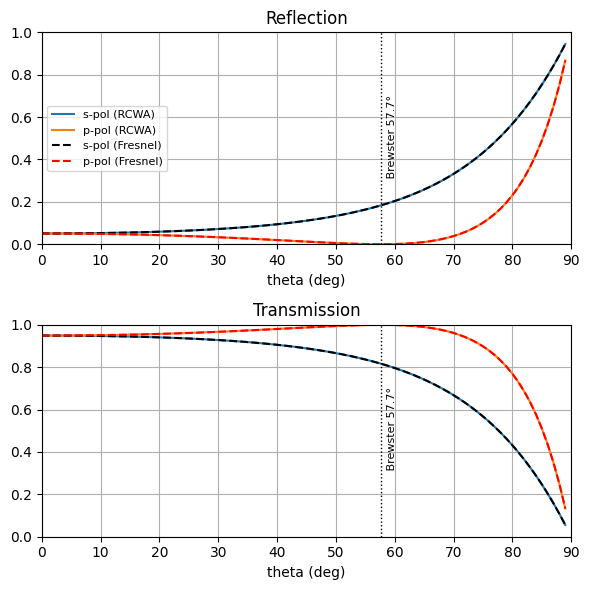

In [ ]:
# Define config
dtype = torch.float32
device = "cuda:0"

# Define model parameters
eps1 = ConstantEps(1.0)
eps2 = ConstantEps(2.5, eps_im=0.0)
period = 400.0
wl = torch.tensor(532.0)
theta = torch.linspace(0.0, 89.0, 90)*torch.pi/180.0
phi = torch.tensor([0.0])

# Solve
model = build_model(eps1, eps2, period, wl, theta, phi)
config = build_config(dtype, device)
Rs, Rp, Ts, Tp = compute_rt(model, config)

# Analytic reference + Brewster angle
n1, n2 = eps1(wl).item()**0.5, eps2(wl).item()**0.5
Rs_t, Rp_t, Ts_t, Tp_t = fresnel_rt(n1, n2, theta)
theta_B = brewster_angle(n1.real, n2.real)

# Plot
theta_deg = theta*180.0/torch.pi
plot_rt(
    theta_deg,
    solver=(Rs[0, :, 0], Rp[0, :, 0], Ts[0, :, 0], Tp[0, :, 0]),
    theory=(Rs_t, Rp_t, Ts_t, Tp_t),
    marks=[(theta_B, f"Brewster {theta_B:.1f}°")],
)

## 2. Total internal reflection

`n1=sqrt(2)` &rarr; `n2=1` (`eps1=2`, `eps2=1`): going from a denser to a
rarer medium. Beyond the critical angle `theta_c = asin(n2/n1)`, no real
transmission angle exists (Snell's law would require `sin(theta_t) > 1`) —
all power is reflected (`R=1`, `T=0`) for both polarizations. Here
`theta_c = asin(1/sqrt(2)) = 45°` exactly.

This sweep passes directly through `theta_c`, which is also exactly the
grazing-incidence degeneracy (`kz &rarr; 0` in the transmission medium) that
`Config.grazing_eps_reg` regularizes — without it, the boundary S-matrix
solve is exactly singular at this angle.

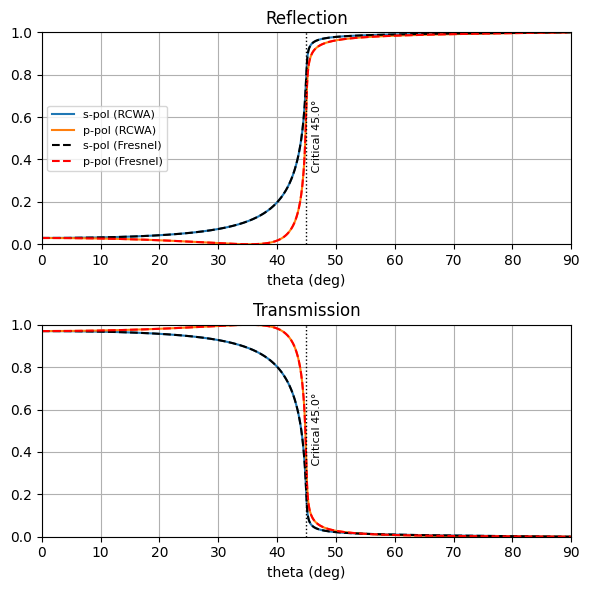

In [47]:
# Define config
dtype = torch.float32
device = "cuda:0"

# Define model parameters
eps1 = ConstantEps(2.0)
eps2 = ConstantEps(1.0, eps_im=0.005)
period = 400.0
wl = torch.tensor(532.0)
theta = torch.linspace(0.0, 89.9, 900)*torch.pi/180.0
phi = torch.tensor([0.0])

# Solve
model = build_model(eps1, eps2, period, wl, theta, phi)
config = build_config(dtype, device)
Rs, Rp, Ts, Tp = compute_rt(model, config)

# Analytic reference + critical angle
n1, n2 = eps1(wl).item()**0.5, eps2(wl).item()**0.5
Rs_t, Rp_t, Ts_t, Tp_t = fresnel_rt(n1, n2, theta)
theta_c = critical_angle(n1.real, n2.real)

# Plot
theta_deg = theta*180.0/torch.pi
plot_rt(
    theta_deg,
    solver=(Rs[0, :, 0], Rp[0, :, 0], Ts[0, :, 0], Tp[0, :, 0]),
    theory=(Rs_t, Rp_t, Ts_t, Tp_t),
    marks=[(theta_c, f"Critical {theta_c:.1f}°")],
)